In [15]:
import numpy as np
import pandas as pd

# Load inputs
fcf_df = pd.read_csv("../data/final_forecast_fcf.csv")
wacc_df = pd.read_csv("../data/wacc_hdfc.csv")

fcf_values = fcf_df["FCF_Mean"].values
base_wacc = wacc_df["wacc"].values[0]



Reuse DCF Function:

In [16]:
def dcf_valuation(fcf, wacc, g):
    pv_fcf = np.sum([
        fcf[t] / ((1 + wacc) ** (t + 1))
        for t in range(len(fcf))
    ])

    terminal_value = (fcf[-1] * (1 + g)) / (wacc - g)
    pv_terminal = terminal_value / ((1 + wacc) ** len(fcf))

    return pv_fcf + pv_terminal


Monte Carlo Simulation Engine:

In [17]:
def monte_carlo_dcf(
    fcf,
    wacc_mean,
    wacc_std=0.01,
    fcf_noise=0.05,
    g=0.04,
    iterations=10000
):
    valuations = []

    for _ in range(iterations):
        sampled_wacc = np.random.normal(wacc_mean, wacc_std)
        noisy_fcf = fcf * np.random.normal(1, fcf_noise, size=len(fcf))

        if sampled_wacc > g:  # stability condition
            val = dcf_valuation(noisy_fcf, sampled_wacc, g)
            valuations.append(val)

    return np.array(valuations)


Run Simulation:

In [18]:
simulated_values = monte_carlo_dcf(
    fcf=fcf_values,
    wacc_mean=base_wacc
)

simulated_values[:5]


array([1.97995447e+13, 1.84578118e+13, 2.20363739e+13, 2.71627601e+13,
       2.74888713e+13])

Analyze Risk Outputs:

In [19]:
np.percentile(simulated_values, [10, 50, 90])
#p10 - bear case - downside protection
#p50 - fair case - intrinsic value
#p90 - bull case - upside potential


array([1.68833159e+13, 2.01859530e+13, 2.49206401e+13])

Save Results:

In [20]:
mc_df = pd.DataFrame({
    "valuation": simulated_values
})

mc_df.to_csv("../data/monte_carlo_valuation.csv", index=False)


Histogram visualization:

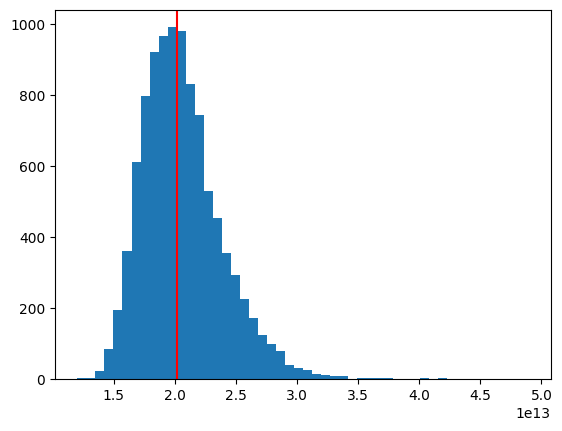

In [21]:
import matplotlib.pyplot as plt

plt.hist(simulated_values, bins=50)
plt.axvline(np.percentile(simulated_values, 50), color="red")


Downside probability:

In [23]:
import pandas as pd

dcf_df = pd.read_csv("../data/dcf_hdfc.csv")
dcf_value = dcf_df.loc[0, "enterprise_value"]

dcf_value



np.float64(20191294588966.17)

In [24]:

np.mean(simulated_values < dcf_value)

np.float64(0.5007)